# ESC-50: Environmental Sound Classification Dataset

## About the Dataset

**ESC-50** is a labeled collection of 2000 environmental audio recordings suitable for benchmarking methods of environmental sound classification.

### Dataset Details:
- **Owner**: Karol J. Piczak (created during his PhD research)
- **Origin**: Published in 2015 as part of research on environmental sound classification
- **Organization**: 
  - 2000 audio clips (5 seconds each)
  - 50 classes (40 samples per class)
  - Organized into 5 folds for cross-validation
  - Sampled at 44.1 kHz, mono
  - Stored as WAV files

### Data Recording:
- Clips are extracted from field recordings available on Freesound.org
- Manually verified and labeled
- Carefully selected to avoid overlapping sources across folds
- Covers 5 major categories: Animals, Natural soundscapes & water sounds, Human non-speech sounds, Interior/domestic sounds, and Exterior/urban noises

**Citation**: Piczak, K. J. (2015). ESC: Dataset for Environmental Sound Classification. In Proceedings of the 23rd ACM international conference on Multimedia (pp. 1015-1018).

## Download ESC-50 Dataset from GitHub

We'll download the dataset from the official GitHub repository. The code will:
- Check if the dataset already exists in our workspace
- Download with a progress bar if needed
- Confirm successful download

In [3]:
%pip install librosa
import os
import zipfile
import requests
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import warnings
URL = "https://github.com/karolpiczak/ESC-50/archive/refs/heads/master.zip"
ZIP_NAME = "ESC-50.zip"
DIR_NAME = "ESC-50-master"

if not os.path.exists(DIR_NAME):
    print("Downloading dataset...")
    urllib.request.urlretrieve(URL, ZIP_NAME)
    with zipfile.ZipFile(ZIP_NAME, 'r') as z:
        z.extractall(".")
    os.remove(ZIP_NAME)

DATA_PATH = os.path.join(DIR_NAME, "audio")
audio_path = os.path.join(DIR_NAME, "audio")

df = pd.read_csv(os.path.join(DIR_NAME, "meta/esc50.csv"))
print(f"Dataset Loaded: {len(df)} samples, {df['target'].nunique()} classes.")

Note: you may need to restart the kernel to use updated packages.
Dataset Loaded: 2000 samples, 50 classes.


## Load and Explore Metadata

Let's load the metadata file which contains information about each audio clip including:
- Filename
- Fold (for cross-validation)
- Target class (numeric label)
- Category (class name)
- ESC-10 flag (subset indicator)
- Source information

In [5]:
# Load metadata
metadata = pd.read_csv(os.path.join(DIR_NAME, "meta/esc50.csv"))

print("Dataset Overview:")
print(f"Total number of audio samples: {len(metadata)}")
print(f"Number of unique classes: {metadata['category'].nunique()}")
print(f"Number of folds: {metadata['fold'].nunique()}")
print(f"\nDataset shape: {metadata.shape}")
print("\n" + "="*50)

# Display first few rows
print("\nFirst 10 samples:")
display(metadata.head(10))

Dataset Overview:
Total number of audio samples: 2000
Number of unique classes: 50
Number of folds: 5

Dataset shape: (2000, 7)


First 10 samples:


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A
5,1-101296-B-19.wav,1,19,thunderstorm,False,101296,B
6,1-101336-A-30.wav,1,30,door_wood_knock,False,101336,A
7,1-101404-A-34.wav,1,34,can_opening,False,101404,A
8,1-103298-A-9.wav,1,9,crow,False,103298,A
9,1-103995-A-30.wav,1,30,door_wood_knock,False,103995,A


In [6]:
# Get summary statistics
print("\nColumn Information:")
print(metadata.info())

print("\n" + "="*50)
print("\nSummary Statistics:")
display(metadata.describe())

print("\n" + "="*50)
print("\nUnique values per column:")
for col in metadata.columns:
    print(f"{col}: {metadata[col].nunique()} unique values")


Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  2000 non-null   object
 1   fold      2000 non-null   int64 
 2   target    2000 non-null   int64 
 3   category  2000 non-null   object
 4   esc10     2000 non-null   bool  
 5   src_file  2000 non-null   int64 
 6   take      2000 non-null   object
dtypes: bool(1), int64(3), object(3)
memory usage: 95.8+ KB
None


Summary Statistics:


,fold,target,src_file
count,2000.000000,2000.000000,2000.000000
mean,3.000000,24.500000,137696.797500
std,1.414567,14.434479,64882.993641
min,1.000000,0.000000,137.000000
25%,2.000000,12.000000,87726.250000
50%,3.000000,24.500000,143745.500000
75%,4.000000,37.000000,188215.000000
max,5.000000,49.000000,264453.000000




Unique values per column:
filename: 2000 unique values
fold: 5 unique values
target: 50 unique values
category: 50 unique values
esc10: 2 unique values
src_file: 1524 unique values
take: 8 unique values


## Distribution Analysis

### Per-Class Distribution
Let's visualize how many samples we have per class and check if the dataset is balanced.

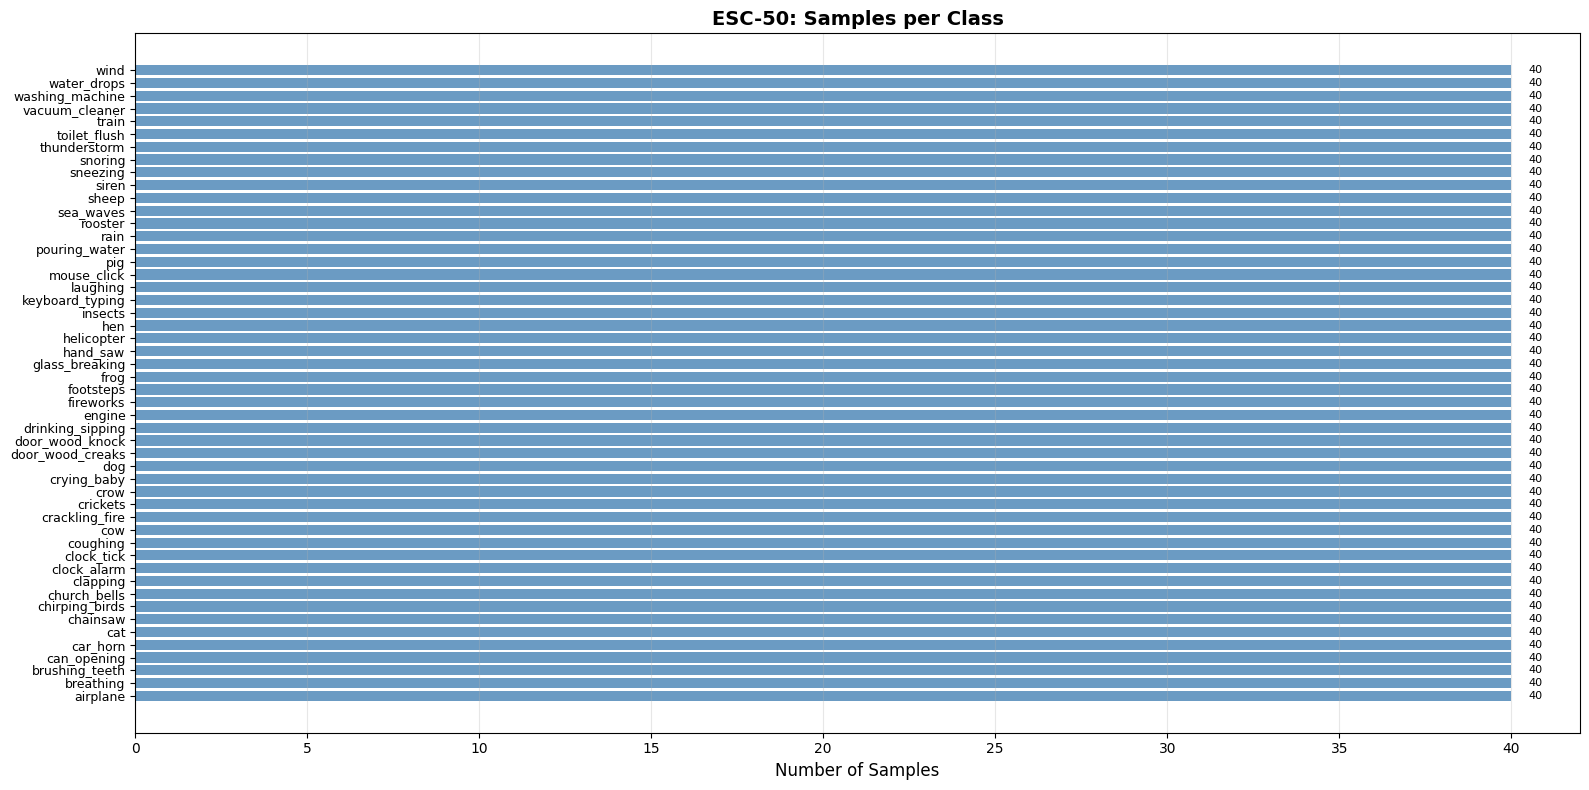


All classes have 40 samples - perfectly balanced! ✓


In [7]:
# Count samples per class
class_counts = metadata['category'].value_counts().sort_index()

# Create figure
plt.figure(figsize=(16, 8))
plt.barh(range(len(class_counts)), class_counts.values, color='steelblue', alpha=0.8)
plt.yticks(range(len(class_counts)), class_counts.index, fontsize=9)
plt.xlabel('Number of Samples', fontsize=12)
plt.title('ESC-50: Samples per Class', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Add count labels on bars
for i, v in enumerate(class_counts.values):
    plt.text(v + 0.5, i, str(v), va='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nAll classes have {class_counts.values[0]} samples - perfectly balanced! ✓")

### Fold Distribution
The dataset is organized into 5 folds for cross-validation. Let's check the distribution across folds.

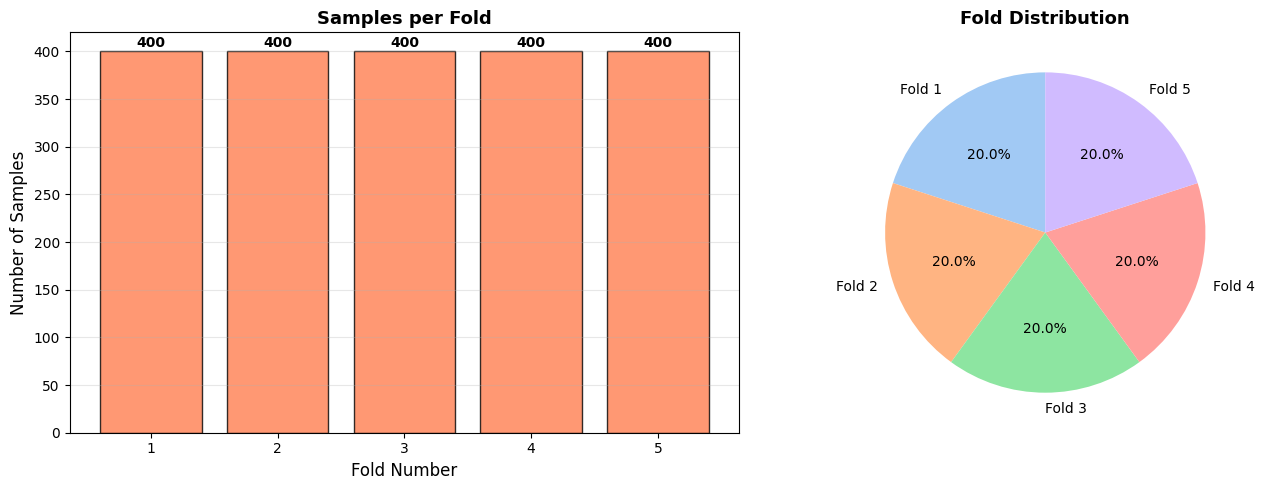


Fold statistics:
Fold 1: 400 samples
Fold 2: 400 samples
Fold 3: 400 samples
Fold 4: 400 samples
Fold 5: 400 samples


In [9]:
# Fold distribution
fold_counts = metadata['fold'].value_counts().sort_index()

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(fold_counts.index, fold_counts.values, color='coral', alpha=0.8, edgecolor='black')
axes[0].set_xlabel('Fold Number', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].set_title('Samples per Fold', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticks(fold_counts.index)

# Add count labels
for i, v in zip(fold_counts.index, fold_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(fold_counts.values, labels=[f'Fold {i}' for i in fold_counts.index], 
            autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
axes[1].set_title('Fold Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nFold statistics:")
for fold, count in fold_counts.items():
    print(f"Fold {fold}: {count} samples")

## Listen to Audio Samples

Let's play 3 random audio samples directly in the notebook to get a feel for the data.

In [10]:
from IPython.display import Audio, display, HTML

# Select 3 random samples
random_samples = metadata.sample(n=3, random_state=42)

print("Playing 3 random audio samples:\n" + "="*60)

for idx, row in random_samples.iterrows():
    audio_file = os.path.join(audio_path, row['filename'])
    
    # Load audio to get duration
    y, sr = librosa.load(audio_file, sr=None)
    duration = librosa.get_duration(y=y, sr=sr)
    
    print(f"\n📢 Sample {idx + 1}:")
    print(f"   Class: {row['category']}")
    print(f"   Filename: {row['filename']}")
    print(f"   Fold: {row['fold']}")
    print(f"   Duration: {duration:.2f} seconds")
    print(f"   Sample rate: {sr} Hz")
    
    # Display audio player
    display(Audio(audio_file))
    print("-" * 60)

Playing 3 random audio samples:

📢 Sample 1861:
   Class: clapping
   Filename: 5-221950-A-22.wav
   Fold: 5
   Duration: 5.00 seconds
   Sample rate: 44100 Hz


------------------------------------------------------------

📢 Sample 354:
   Class: pouring_water
   Filename: 1-79220-A-17.wav
   Fold: 1
   Duration: 5.00 seconds
   Sample rate: 44100 Hz


------------------------------------------------------------

📢 Sample 1334:
   Class: train
   Filename: 4-165845-A-45.wav
   Fold: 4
   Duration: 5.00 seconds
   Sample rate: 44100 Hz


------------------------------------------------------------


## Waveform Exploration

Let's visualize the waveforms of different audio samples to understand their temporal characteristics.

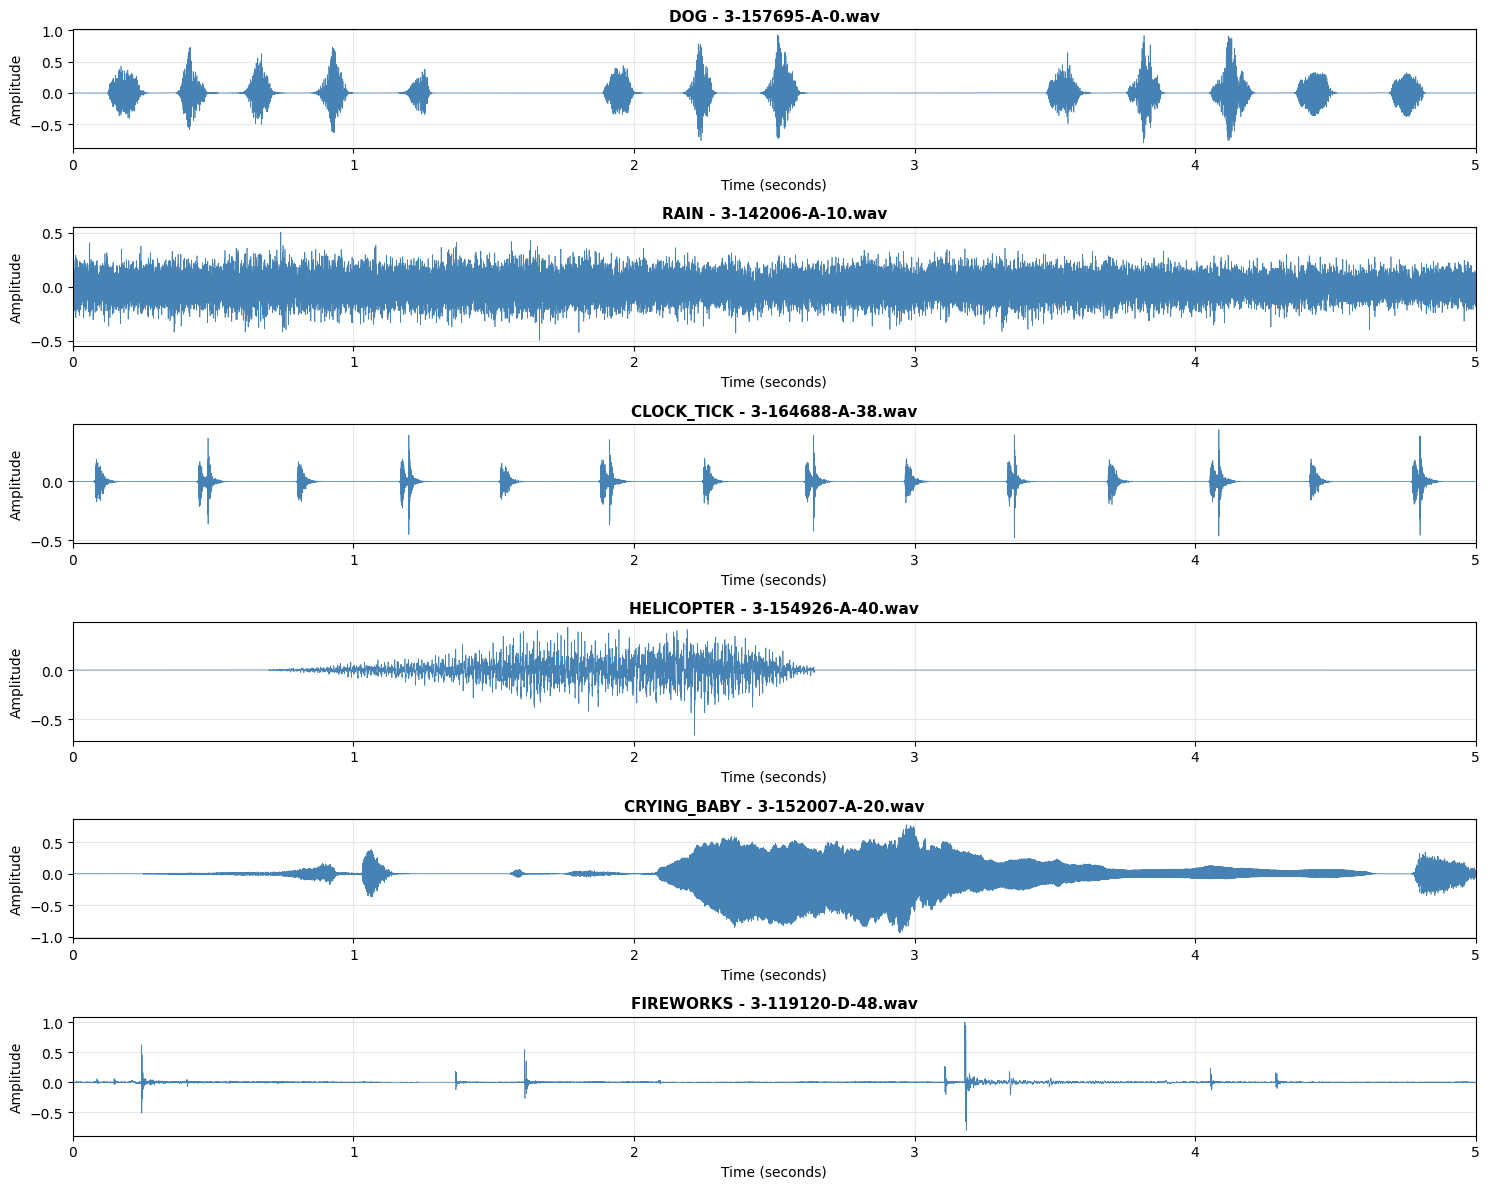

Waveform characteristics vary significantly across sound classes!


In [11]:
# Select samples from different classes for comparison
selected_classes = ['dog', 'rain', 'clock_tick', 'helicopter', 'crying_baby', 'fireworks']
samples_to_plot = []

for cls in selected_classes:
    sample = metadata[metadata['category'] == cls].sample(n=1, random_state=42)
    samples_to_plot.append(sample.iloc[0])

# Create subplots
fig, axes = plt.subplots(len(samples_to_plot), 1, figsize=(15, 12))

for idx, (ax, sample) in enumerate(zip(axes, samples_to_plot)):
    # Load audio
    audio_file = os.path.join(audio_path, sample['filename'])
    y, sr = librosa.load(audio_file, sr=None)
    
    # Plot waveform
    time = np.linspace(0, len(y) / sr, len(y))
    ax.plot(time, y, color='steelblue', linewidth=0.5)
    ax.set_title(f"{sample['category'].upper()} - {sample['filename']}", 
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Time (seconds)', fontsize=10)
    ax.set_ylabel('Amplitude', fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_xlim([0, len(y) / sr])

plt.tight_layout()
plt.show()

print("Waveform characteristics vary significantly across sound classes!")

## Temporal Analysis

### Energy Distribution Over Time
Let's analyze how the audio energy is distributed from the start to the end of each clip, and calculate the percentage of silence in the recordings.

Analyzing temporal characteristics of 100 random samples...



Processing: 100%|██████████| 100/100 [00:00<00:00, 607.64it/s]


✓ Analysis complete!



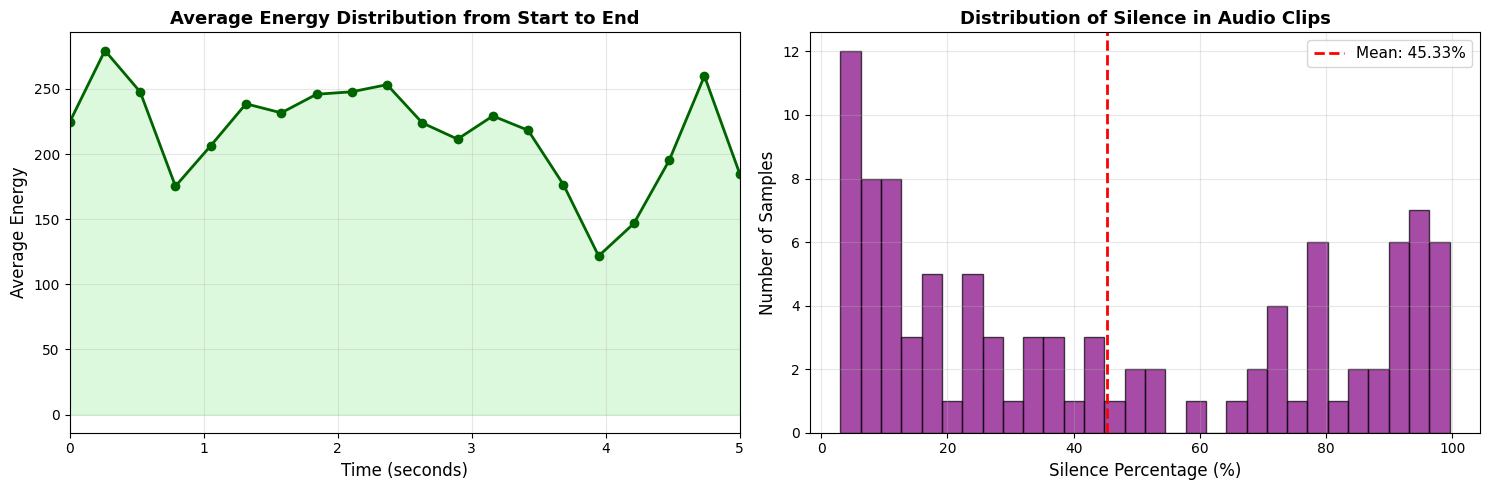


Silence Statistics:
  Average silence: 45.33%
  Minimum silence: 3.04%
  Maximum silence: 99.55%
  Median silence: 35.58%


In [12]:
# Select a sample of files to analyze (to avoid processing all 2000 files)
np.random.seed(42)
sample_files = metadata.sample(n=100, random_state=42)

# Initialize arrays to store temporal data
num_bins = 20  # Divide each audio into 20 time bins
average_energy_distribution = np.zeros(num_bins)
silence_percentages = []

print("Analyzing temporal characteristics of 100 random samples...\n")

for idx, row in tqdm(sample_files.iterrows(), total=len(sample_files), desc="Processing"):
    audio_file = os.path.join(audio_path, row['filename'])
    y, sr = librosa.load(audio_file, sr=None)
    
    # Calculate energy in each time bin
    samples_per_bin = len(y) // num_bins
    for i in range(num_bins):
        start = i * samples_per_bin
        end = start + samples_per_bin if i < num_bins - 1 else len(y)
        bin_energy = np.sum(y[start:end] ** 2)
        average_energy_distribution[i] += bin_energy
    
    # Calculate silence percentage (threshold: 0.01 amplitude)
    silence_threshold = 0.01
    silent_samples = np.sum(np.abs(y) < silence_threshold)
    silence_pct = (silent_samples / len(y)) * 100
    silence_percentages.append(silence_pct)

# Normalize average energy distribution
average_energy_distribution /= len(sample_files)

print("\n✓ Analysis complete!\n")

# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Average energy distribution over time
time_bins = np.linspace(0, 5, num_bins)  # 5 seconds
axes[0].plot(time_bins, average_energy_distribution, marker='o', linewidth=2, 
             markersize=6, color='darkgreen')
axes[0].fill_between(time_bins, average_energy_distribution, alpha=0.3, color='lightgreen')
axes[0].set_xlabel('Time (seconds)', fontsize=12)
axes[0].set_ylabel('Average Energy', fontsize=12)
axes[0].set_title('Average Energy Distribution from Start to End', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].set_xlim([0, 5])

# Plot 2: Silence percentage distribution
axes[1].hist(silence_percentages, bins=30, color='purple', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Silence Percentage (%)', fontsize=12)
axes[1].set_ylabel('Number of Samples', fontsize=12)
axes[1].set_title('Distribution of Silence in Audio Clips', fontsize=13, fontweight='bold')
axes[1].axvline(np.mean(silence_percentages), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {np.mean(silence_percentages):.2f}%')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nSilence Statistics:")
print(f"  Average silence: {np.mean(silence_percentages):.2f}%")
print(f"  Minimum silence: {np.min(silence_percentages):.2f}%")
print(f"  Maximum silence: {np.max(silence_percentages):.2f}%")
print(f"  Median silence: {np.median(silence_percentages):.2f}%")

## Additional Data Exploration Techniques

### Spectrogram Analysis
Spectrograms show how the frequency content of the audio changes over time - a powerful visualization for audio data.

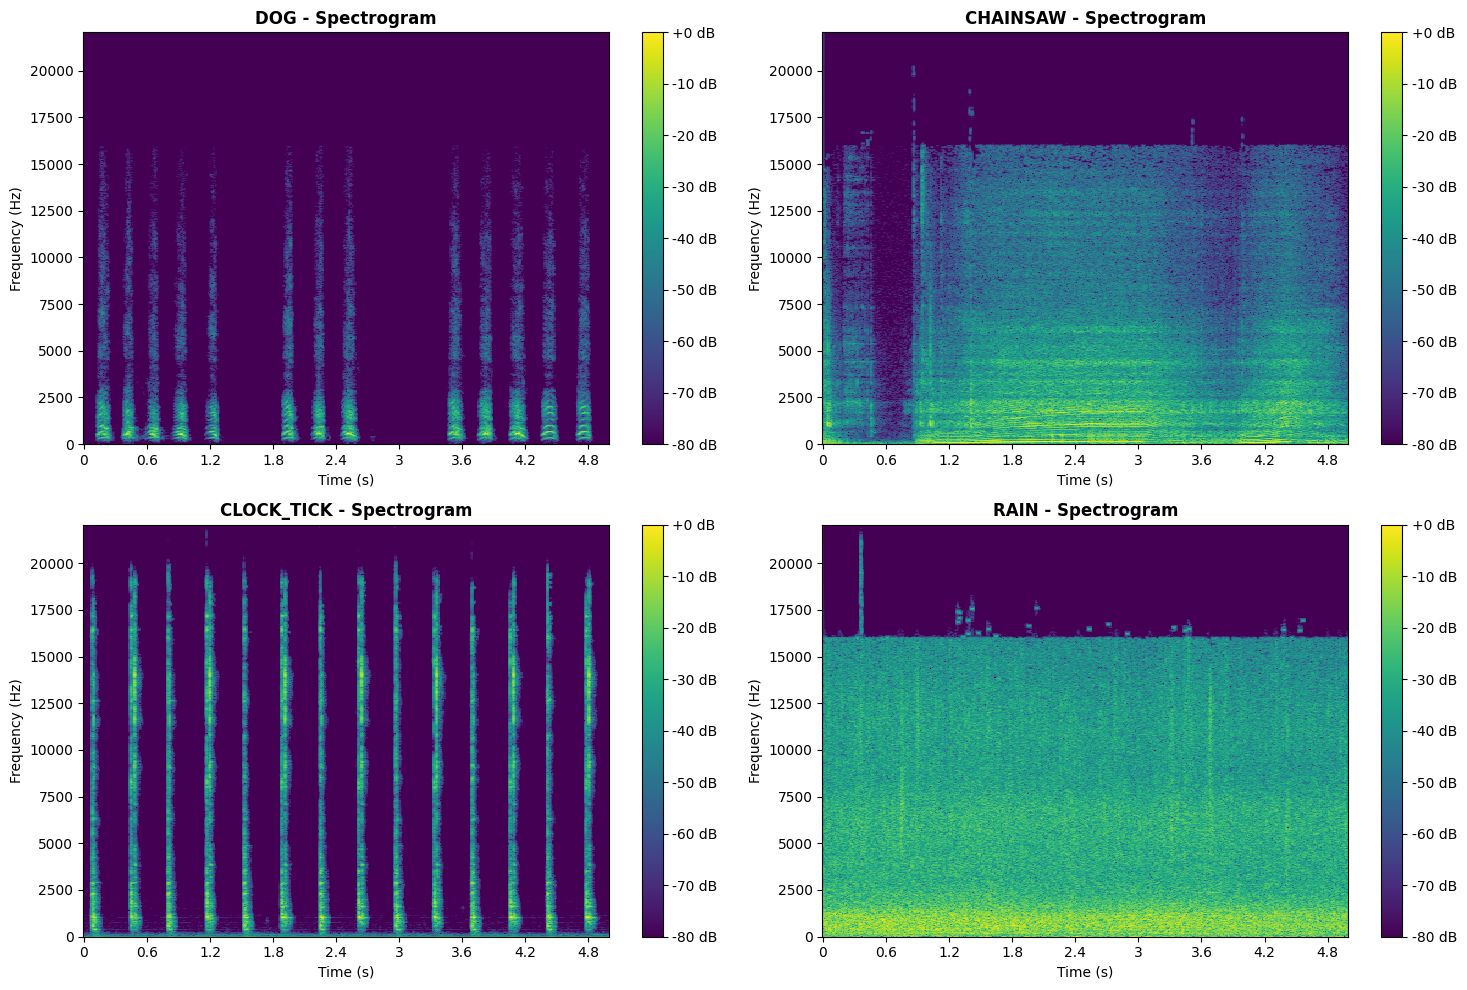

Spectrograms reveal unique frequency patterns for each sound class!


In [13]:
# Select diverse samples for spectrogram analysis
selected_for_spec = ['dog', 'chainsaw', 'clock_tick', 'rain']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, cls in enumerate(selected_for_spec):
    # Get a sample from this class
    sample = metadata[metadata['category'] == cls].sample(n=1, random_state=42).iloc[0]
    audio_file = os.path.join(audio_path, sample['filename'])
    
    # Load audio
    y, sr = librosa.load(audio_file, sr=None)
    
    # Compute spectrogram
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    
    # Plot
    img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=axes[idx], cmap='viridis')
    axes[idx].set_title(f'{cls.upper()} - Spectrogram', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Time (s)', fontsize=10)
    axes[idx].set_ylabel('Frequency (Hz)', fontsize=10)
    fig.colorbar(img, ax=axes[idx], format='%+2.0f dB')

plt.tight_layout()
plt.show()

print("Spectrograms reveal unique frequency patterns for each sound class!")

### Audio File Statistics
Let's analyze various audio properties across the dataset.

In [16]:
# Analyze a sample of files for statistics
sample_size = 200
analysis_sample = metadata.sample(n=sample_size, random_state=42)

audio_stats = []

print(f"Analyzing audio properties for {sample_size} samples...\n")

for idx, row in tqdm(analysis_sample.iterrows(), total=len(analysis_sample), desc="Processing"):
    audio_file = os.path.join(audio_path, row['filename'])
    y, sr = librosa.load(audio_file, sr=None)
    
    # Calculate various statistics
    duration = librosa.get_duration(y=y, sr=sr)
    rms_energy = np.sqrt(np.mean(y**2))
    zero_crossing_rate = np.mean(librosa.feature.zero_crossing_rate(y))
    spectral_centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    
    audio_stats.append({
        'category': row['category'],
        'duration': duration,
        'rms_energy': rms_energy,
        'zero_crossing_rate': zero_crossing_rate,
        'spectral_centroid': spectral_centroid
    })

stats_df = pd.DataFrame(audio_stats)

print("\n✓ Analysis complete!\n")
print("Audio Statistics Summary:")
display(stats_df.describe())

Analyzing audio properties for 200 samples...



Processing: 100%|██████████| 200/200 [00:03<00:00, 54.85it/s]


✓ Analysis complete!

Audio Statistics Summary:


,duration,rms_energy,zero_crossing_rate,spectral_centroid
count,200.0,200.000000,200.000000,200.000000
mean,5.0,0.096057,0.074515,2907.036465
std,0.0,0.087370,0.069285,1868.477433
min,5.0,0.003557,0.003742,224.989851
25%,5.0,0.025518,0.028043,1481.275308
50%,5.0,0.073472,0.052749,2565.158247
75%,5.0,0.145174,0.093949,3761.110438
max,5.0,0.405347,0.464387,10993.876797


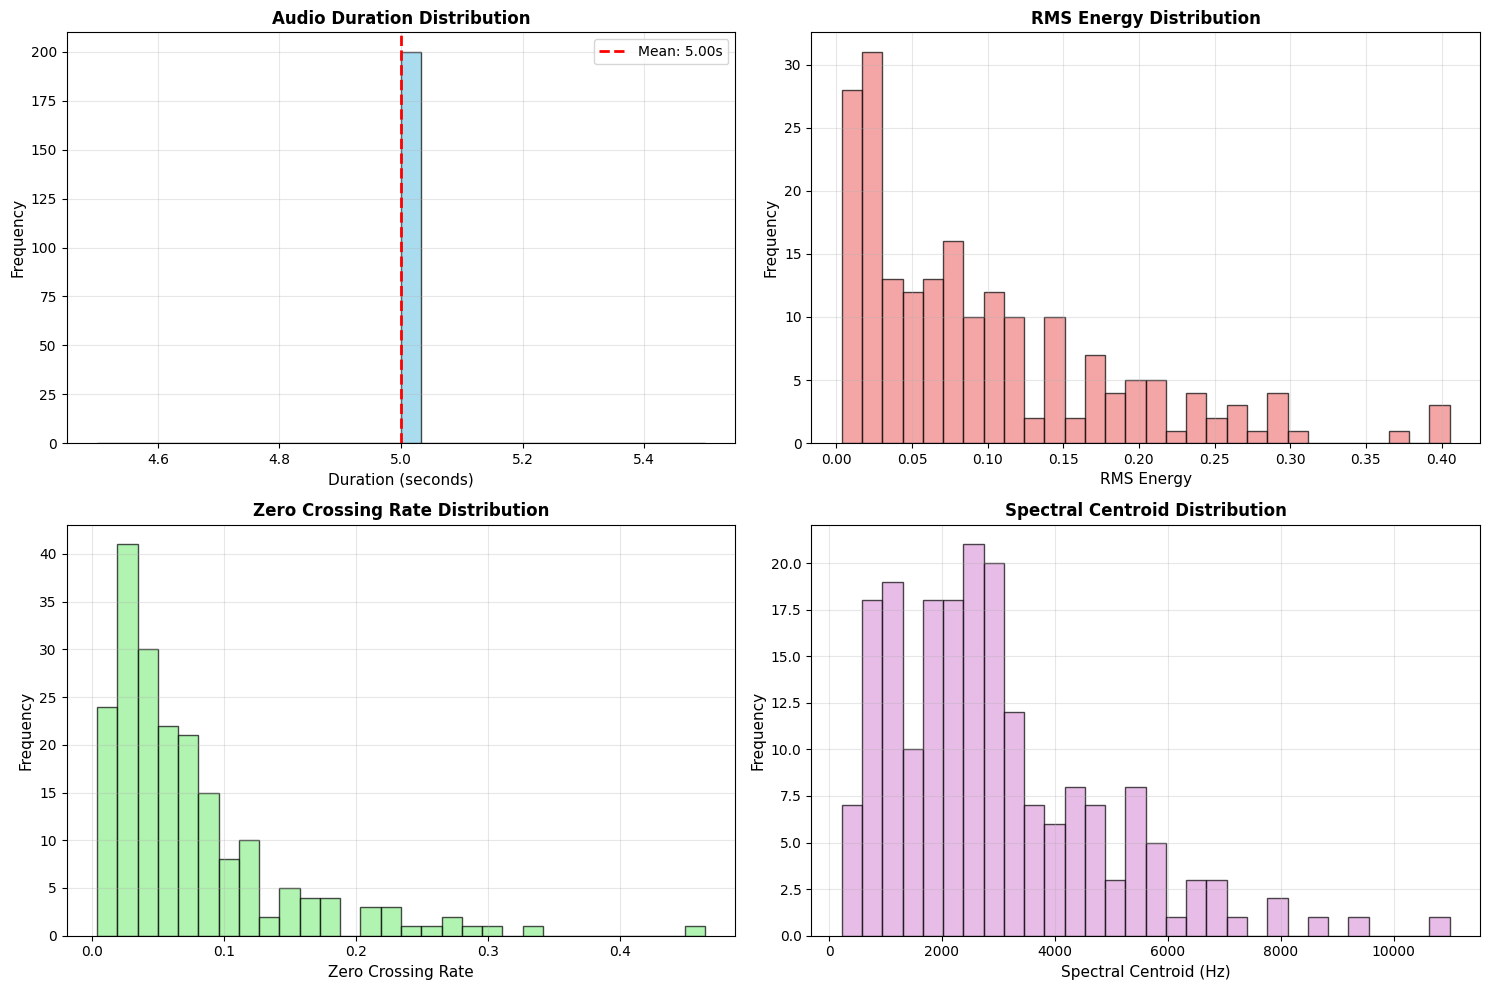


Key Insights:
  • All clips are approximately 5.00 seconds long
  • Average RMS energy: 0.0961
  • Zero-crossing rate indicates audio texture and percussiveness
  • Spectral centroid shows the 'brightness' of sounds


In [17]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Duration distribution
axes[0, 0].hist(stats_df['duration'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Duration (seconds)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Audio Duration Distribution', fontsize=12, fontweight='bold')
axes[0, 0].axvline(stats_df['duration'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {stats_df["duration"].mean():.2f}s')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: RMS Energy distribution
axes[0, 1].hist(stats_df['rms_energy'], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('RMS Energy', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('RMS Energy Distribution', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Plot 3: Zero Crossing Rate
axes[1, 0].hist(stats_df['zero_crossing_rate'], bins=30, color='lightgreen', 
                edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Zero Crossing Rate', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Zero Crossing Rate Distribution', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Plot 4: Spectral Centroid
axes[1, 1].hist(stats_df['spectral_centroid'], bins=30, color='plum', 
                edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Spectral Centroid (Hz)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Spectral Centroid Distribution', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Insights:")
print(f"  • All clips are approximately {stats_df['duration'].mean():.2f} seconds long")
print(f"  • Average RMS energy: {stats_df['rms_energy'].mean():.4f}")
print(f"  • Zero-crossing rate indicates audio texture and percussiveness")
print(f"  • Spectral centroid shows the 'brightness' of sounds")

### Audio Properties by Category
Let's see how different audio properties vary across sound categories.

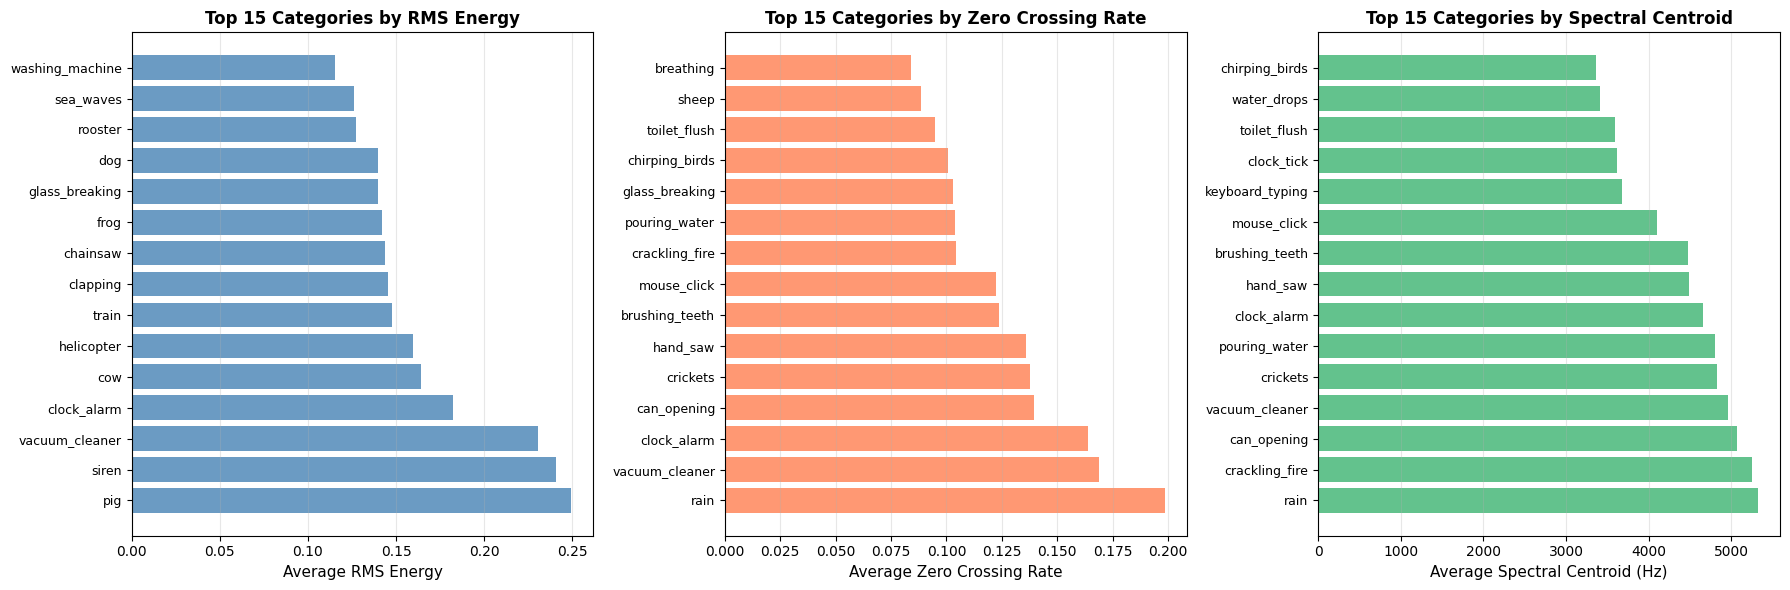


Different sound categories exhibit distinct acoustic properties!
This suggests that machine learning models can effectively distinguish between classes.


In [18]:
# Calculate average properties per category
category_stats = stats_df.groupby('category').agg({
    'rms_energy': 'mean',
    'zero_crossing_rate': 'mean',
    'spectral_centroid': 'mean'
}).reset_index()

# Sort by RMS energy
category_stats = category_stats.sort_values('rms_energy', ascending=False).head(15)

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# RMS Energy by category
axes[0].barh(range(len(category_stats)), category_stats['rms_energy'], color='steelblue', alpha=0.8)
axes[0].set_yticks(range(len(category_stats)))
axes[0].set_yticklabels(category_stats['category'], fontsize=9)
axes[0].set_xlabel('Average RMS Energy', fontsize=11)
axes[0].set_title('Top 15 Categories by RMS Energy', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Zero Crossing Rate by category
category_stats_zcr = stats_df.groupby('category')['zero_crossing_rate'].mean().sort_values(ascending=False).head(15)
axes[1].barh(range(len(category_stats_zcr)), category_stats_zcr.values, color='coral', alpha=0.8)
axes[1].set_yticks(range(len(category_stats_zcr)))
axes[1].set_yticklabels(category_stats_zcr.index, fontsize=9)
axes[1].set_xlabel('Average Zero Crossing Rate', fontsize=11)
axes[1].set_title('Top 15 Categories by Zero Crossing Rate', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

# Spectral Centroid by category
category_stats_sc = stats_df.groupby('category')['spectral_centroid'].mean().sort_values(ascending=False).head(15)
axes[2].barh(range(len(category_stats_sc)), category_stats_sc.values, color='mediumseagreen', alpha=0.8)
axes[2].set_yticks(range(len(category_stats_sc)))
axes[2].set_yticklabels(category_stats_sc.index, fontsize=9)
axes[2].set_xlabel('Average Spectral Centroid (Hz)', fontsize=11)
axes[2].set_title('Top 15 Categories by Spectral Centroid', fontsize=12, fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nDifferent sound categories exhibit distinct acoustic properties!")
print("This suggests that machine learning models can effectively distinguish between classes.")

## Exploration Summary

### Key Findings:

1. **Dataset Structure**:
   - 2000 audio clips across 50 balanced classes
   - 5-fold cross-validation structure
   - Each clip is exactly 5 seconds long at 44.1 kHz

2. **Audio Characteristics**:
   - Varying energy distributions across time
   - Different levels of silence depending on sound type
   - Distinct spectral signatures for different categories

3. **Feature Patterns**:
   - RMS energy varies significantly across categories
   - Zero-crossing rates indicate texture differences
   - Spectral centroids reveal frequency characteristics

4. **Data Quality**:
   - Well-balanced dataset (40 samples per class)
   - Consistent audio format and duration
   - Suitable for machine learning classification tasks

### Next Steps:
- Feature extraction (MFCCs, mel-spectrograms, etc.)
- Model training and evaluation
- Cross-validation using the provided folds
- Performance benchmarking

---

**Dataset is ready for machine learning experiments! **
